# One-Time Final Evaluation of the Locked 149-Case Symbolic Model

This notebook opens the sealed 50-case final set exactly once for reporting.

## Frozen model roles

- **Primary deployment model:** `mean_calibrated_consensus`.
- **Secondary research model:** `full_consensus_tail`, using the predeclared
  active tail rotations 1, 2 and 3 at fixed gain 1.0.
- The secondary result cannot replace the primary because of final-test
  performance.

## Irreversible evaluation contract

- No fitting, constant refit, formula search, gain selection, threshold tuning
  or model promotion is permitted.
- Every element in all 50 final cases is evaluated by both frozen models.
- A fixed sample is used only to render publication figures; it is never used
  to calculate reported metrics.
- The thresholds are project research-reporting thresholds, not nuclear safety
  or licensing limits.
- Failed thresholds are reported as limitations and do not reopen development.
- An interrupted identical run may resume signed per-case caches. A completed
  run refuses re-execution.


## 1. Resolve the package and import the locked evaluator


In [1]:
from pathlib import Path
import json
import os
import sys

import pandas as pd

try:
    from IPython.display import Image, display
except Exception:
    display = print
    Image = None


def resolve_package_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src" / "final_locked_149_evaluation.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NotebookCT3 package root")


PACKAGE_ROOT = resolve_package_root()
if str(PACKAGE_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT / "src"))

from final_locked_149_evaluation import (
    LockedFinal149Config,
    PRIMARY_MODEL,
    PRIMARY_ROLE,
    SECONDARY_MODEL,
    SECONDARY_ROLE,
    output_directory,
    preflight_locked_final_149,
    run_locked_final_149,
)

print("Package root:", PACKAGE_ROOT)
print("Python:", sys.executable)
print("Explicit final-run authorisation:", os.environ.get("CT3_AUTHORISE_LOCKED_FINAL_TEST"))


Package root: /net/scratch/j96317yn/NotebookCT3
Python: /net/scratch/j96317yn/NotebookCT3/.venv/bin/python
Explicit final-run authorisation: YES


## 2. Predeclared metrics, thresholds and read-free preflight


In [2]:
CONFIG = LockedFinal149Config()
OUTPUT_DIR = output_directory(PACKAGE_ROOT, CONFIG)
PREFLIGHT = preflight_locked_final_149(PACKAGE_ROOT, CONFIG)

print("Primary:", PRIMARY_MODEL, "-", PRIMARY_ROLE)
print("Secondary:", SECONDARY_MODEL, "-", SECONDARY_ROLE)
print("Locked final cases:", len(PREFLIGHT["final_ids"]))
print("Signature:", PREFLIGHT["signature"]["final_evaluation_signature_sha256"])
print("Output directory:", OUTPUT_DIR)
display(PREFLIGHT["checks"])
display(pd.DataFrame([CONFIG.__dict__]).T.rename(columns={0: "locked_value"}))


Primary: mean_calibrated_consensus - predeclared_primary
Secondary: full_consensus_tail - predeclared_secondary_research_only
Locked final cases: 50
Signature: 5139fe57e964f6d522e388431cd9821fb629a84bee9ff7ec085fdc7e0639f1a4
Output directory: /net/scratch/j96317yn/NotebookCT3/outputs/19_one_time_final_50case_locked_149/formal_final_50case


,check,value,expected,pass
0,case_files,199,199,True
1,development_cases,149,149,True
2,final_cases,50,50,True
3,final_manifest_matches,True,True,True
4,integration_complete,complete,complete,True
5,integration_final_values_unread,0,0,True
6,locked_primary,mean_calibrated_consensus,mean_calibrated_consensus,True
7,locked_manifest_primary,mean_calibrated_consensus,mean_calibrated_consensus,True
8,locked_manifest_final_values_unread,0,0,True
9,technical_release_ready,ready_for_human_review_before_one_time_final_test,ready_for_human_review_before_one_time_final_test,True


,locked_value
output_subdir,formal_final_50case
bootstrap_resamples,10000
plot_sample_rows_per_case,5000
random_seed,42
primary_macro_rmse_max,2.0
primary_macro_r2_min,0.45
primary_worst_case_rmse_max,3.5
primary_p95_relative_error_max,0.1
primary_p99_relative_error_max,0.25
primary_p99_underprediction_max,0.25


## 3. Open the sealed set once, or resume the exact signed run


In [3]:
if os.environ.get("CT3_AUTHORISE_LOCKED_FINAL_TEST") != "YES":
    raise PermissionError(
        "Final cases remain closed. Use the approved CSF3 submission command "
        "with CT3_AUTHORISE_LOCKED_FINAL_TEST=YES."
    )

RESULT = run_locked_final_149(PACKAGE_ROOT, CONFIG, preflight=PREFLIGHT)
display(pd.DataFrame([RESULT]).T.rename(columns={0: "value"}))


[1/50] LOCKED FINAL 149: case_00 (evaluate all elements)


[2/50] LOCKED FINAL 149: case_02 (evaluate all elements)


[3/50] LOCKED FINAL 149: case_03 (evaluate all elements)


[4/50] LOCKED FINAL 149: case_04 (evaluate all elements)


[5/50] LOCKED FINAL 149: case_05 (evaluate all elements)


...

[47/50] LOCKED FINAL 149: case_174 (evaluate all elements)


[48/50] LOCKED FINAL 149: case_177 (evaluate all elements)


[49/50] LOCKED FINAL 149: case_178 (evaluate all elements)


[50/50] LOCKED FINAL 149: case_198 (evaluate all elements)


,value
status,complete
primary_model,mean_calibrated_consensus
secondary_model,full_consensus_tail
primary_role,predeclared_primary
secondary_role,predeclared_secondary_research_only
final_test_cases_read,50
final_test_elements_evaluated_per_model,20018000
models_evaluated,2
final_evaluation_signature_sha256,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...
training_performed,False


## 4. Final metrics and predeclared reporting gates


In [4]:
artifacts = {
    "completion": OUTPUT_DIR / "final_evaluation_complete.json",
    "scope_metrics": OUTPUT_DIR / "final_50case_scope_metrics.csv",
    "case_metrics": OUTPUT_DIR / "final_50case_case_metrics.csv.gz",
    "reporting_gates": OUTPUT_DIR / "final_primary_research_reporting_gates.csv",
    "bootstrap": OUTPUT_DIR / "final_similarity_group_bootstrap_ci.csv",
    "generalisation": OUTPUT_DIR / "development_to_final_generalisation.csv",
    "coverage": OUTPUT_DIR / "final_predictor_coverage_against_development.csv",
    "boundaries": OUTPUT_DIR / "final_provisional_physical_boundary_report.csv",
    "worst_cases": OUTPUT_DIR / "final_worst_15_primary_cases_by_rmse.csv",
    "figures": OUTPUT_DIR / "figure_manifest_for_thesis.csv",
    "formula": OUTPUT_DIR / "frozen_symbolic_formulas_evaluated.txt",
}
for name, path in artifacts.items():
    print(f"{name:18s} exists={path.exists()}  {path}")

for key in [
    "scope_metrics",
    "reporting_gates",
    "bootstrap",
    "generalisation",
    "coverage",
    "worst_cases",
    "figures",
]:
    print(f"\n{key}")
    display(pd.read_csv(artifacts[key]))


completion         exists=True  /net/scratch/j96317yn/NotebookCT3/outputs/19_one_time_final_50case_locked_149/formal_final_50case/final_evaluation_complete.json
scope_metrics      exists=True  /net/scratch/j96317yn/NotebookCT3/outputs/19_one_time_final_50case_locked_149/formal_final_50case/final_50case_scope_metrics.csv
case_metrics       exists=True  /net/scratch/j96317yn/NotebookCT3/outputs/19_one_time_final_50case_locked_149/formal_final_50case/final_50case_case_metrics.csv.gz
reporting_gates    exists=True  /net/scratch/j96317yn/NotebookCT3/outputs/19_one_time_final_50case_locked_149/formal_final_50case/final_primary_research_reporting_gates.csv
bootstrap          exists=True  /net/scratch/j96317yn/NotebookCT3/outputs/19_one_time_final_50case_locked_149/formal_final_50case/final_similarity_group_bootstrap_ci.csv
generalisation     exists=True  /net/scratch/j96317yn/NotebookCT3/outputs/19_one_time_final_50case_locked_149/formal_final_50case/development_to_final_generalisation.csv
co

,evaluation_scope,model,model_role,n_cases,n_elements_evaluated,micro_mae,micro_rmse,micro_r2,macro_mae,macro_rmse,...,mean_top5_actual_rmse,mean_top5_actual_bias,mean_p95_relative_error,mean_p95_underprediction_fraction,mean_p99_relative_error,mean_p99_underprediction_fraction,mean_top5pct_hotspot_overlap,mean_top1pct_hotspot_overlap,mean_top1_recall_in_predicted_top5,max_prediction_abs_max_ratio
0,locked_final_50,full_consensus_tail,predeclared_secondary_research_only,50,20018000,1.348753,1.90587,0.620676,1.348753,1.790679,...,3.284317,-1.960944,0.070953,0.014593,0.170392,0.159277,0.568876,0.556948,0.933417,1.412645
1,locked_final_50,mean_calibrated_consensus,predeclared_primary,50,20018000,1.357319,1.95038,0.602752,1.357319,1.847230,...,3.907870,-2.701038,0.078647,0.047387,0.203084,0.193944,0.506943,0.499720,0.839206,1.346368



reporting_gates


,gate,model,value,threshold,comparison,pass,threshold_role,consequence
0,complete_case_count,mean_calibrated_consensus,5.000000e+01,50.00,equal,True,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
1,complete_element_count,mean_calibrated_consensus,2.001800e+07,20018000.00,equal,True,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
2,macro_rmse,mean_calibrated_consensus,1.847230e+00,2.00,less_equal,True,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
3,macro_r2,mean_calibrated_consensus,3.679875e-01,0.45,greater_equal,False,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
4,worst_case_rmse,mean_calibrated_consensus,4.210844e+00,3.50,less_equal,False,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
5,p95_relative_error,mean_calibrated_consensus,7.864669e-02,0.10,less_equal,True,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
6,p99_relative_error,mean_calibrated_consensus,2.030843e-01,0.25,less_equal,True,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
7,p99_underprediction,mean_calibrated_consensus,1.939445e-01,0.25,less_equal,True,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
8,top1_hotspot_overlap,mean_calibrated_consensus,4.997203e-01,0.45,greater_equal,True,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...
9,top1_recall_in_predicted_top5,mean_calibrated_consensus,8.392058e-01,0.80,greater_equal,True,predeclared_project_research_reporting_thresho...,report_result_only; never tune or reselect usi...



bootstrap


...

,predictor_summary,development_case_min,development_case_max,final_case_min,final_case_max,n_final_cases_below_development,n_final_cases_above_development,n_final_cases_outside_development
0,fluence_rate_mean,3.123689,5.071427,3.075801,5.093768,2,2,4
1,fluence_rate_std,0.230920,0.405617,0.168183,0.404199,4,0,4
2,fluence_rate_min,2.738358,3.191044,2.745657,3.296232,0,4,4
3,fluence_rate_p95,3.676457,5.266848,3.606639,5.283920,2,2,4
4,fluence_rate_max,5.072034,5.386351,5.078251,5.390149,0,2,2
5,temperature_mean,352.432648,441.106537,351.410646,446.718091,1,3,4
6,temperature_std,6.197383,19.903631,10.041429,19.555850,0,0,0
7,temperature_min,341.685638,362.376984,341.423035,362.931732,2,1,3
8,temperature_p95,368.224518,448.746918,367.916931,451.426239,1,3,4
9,temperature_max,420.613190,453.287659,421.484894,452.875305,0,0,0



worst_cases


,evaluation_scope,model,model_role,case_id,case_number,similarity_group,case_mean_correction_mpa,tail_consensus_std_mpa,tail_gain,final_evaluation_signature_sha256,...,max_relative_error,prediction_abs_max_ratio,top5pct_hotspot_overlap,top1pct_hotspot_overlap,top1_recall_in_predicted_top5,negative_prediction_fraction,sum_absolute_error,sum_squared_error,actual_sum,actual_squared_sum
0,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_31,31,group_022,-0.520971,0.530861,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.346368,1.346368,0.497552,0.380869,0.875874,0.010226,1.549713e+06,7.098867e+06,9.014130e+05,3.851288e+06
1,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_174,174,group_138,-0.706119,0.806522,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.171737,0.828263,0.618843,0.554196,0.996254,0.168508,1.065616e+06,4.724987e+06,6.431946e+05,8.869171e+06
2,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_38,38,group_029,-0.662911,0.709222,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.055680,0.944320,0.588321,0.523726,0.979021,0.070841,1.063382e+06,4.471867e+06,9.292539e+05,6.866033e+06
3,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_177,177,group_140,-0.682852,0.854521,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.031825,1.031825,0.620791,0.546703,0.997752,0.143179,9.716451e+05,3.865205e+06,9.043688e+05,8.896794e+06
4,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_26,26,group_018,-0.583368,0.343084,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.302899,1.302899,0.439504,0.506993,0.891359,0.022505,8.631265e+05,2.514557e+06,7.529244e+05,1.986457e+06
5,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_53,53,group_032,-0.488996,0.611173,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.199208,0.800792,0.485813,0.505994,0.793706,0.047060,6.471918e+05,2.049159e+06,2.538084e+06,2.088940e+07
6,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_41,41,group_032,-0.490705,0.617256,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.224933,0.775067,0.506294,0.508991,0.817932,0.045816,6.415988e+05,2.041993e+06,2.530446e+06,2.081534e+07
7,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_161,161,group_126,-0.531304,0.576108,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.285709,0.714291,0.497302,0.509491,0.841409,0.045819,6.189620e+05,1.904872e+06,2.414722e+06,1.918887e+07
8,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_55,55,group_042,-0.483282,0.563143,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.290078,0.709922,0.470527,0.516733,0.828172,0.048199,6.340188e+05,1.880699e+06,2.459248e+06,1.952031e+07
9,locked_final_50,mean_calibrated_consensus,predeclared_primary,case_22,22,group_015,-0.627483,0.531032,0.0,5139fe57e964f6d522e388431cd9821fb629a84bee9ff7...,...,0.165592,0.834408,0.476821,0.503247,0.801948,0.031914,6.069806e+05,1.779567e+06,2.262449e+06,1.638053e+07



figures


,figure,purpose,data_basis,suggested_thesis_section
0,01_final_model_metric_dashboard.png,Primary/secondary final metric dashboard with ...,all final elements,Results overview
1,02_final_case_rmse_r2_rankings.png,Case-level stability and difficult-case ranking,all final elements,Generalisation stability
2,03_final_quantile_calibration.png,"P95, P99 and maximum-stress calibration",all final elements,High-stress accuracy
3,04_final_tail_hotspot_case_metrics.png,Per-case P99 error and hotspot overlap,all final elements,Tail and hotspot analysis
4,05_final_residual_diagnostics.png,Global prediction and residual density,fixed uniform plot sample only,Residual diagnostics
5,06_development_to_final_comparison.png,Development-to-final generalisation shift,all development/final metrics,Generalisation discussion
6,07_best_case_spatial_stress_and_residual.png,Spatial FEM/prediction/residual comparison for...,fixed uniform plot sample; case metrics use al...,Spatial case study
7,07_median_case_spatial_stress_and_residual.png,Spatial FEM/prediction/residual comparison for...,fixed uniform plot sample; case metrics use al...,Spatial case study
8,07_worst_case_spatial_stress_and_residual.png,Spatial FEM/prediction/residual comparison for...,fixed uniform plot sample; case metrics use al...,Spatial case study


## 5. Thesis-ready figures



01_final_model_metric_dashboard.png: Primary/secondary final metric dashboard with preregistered project thresholds


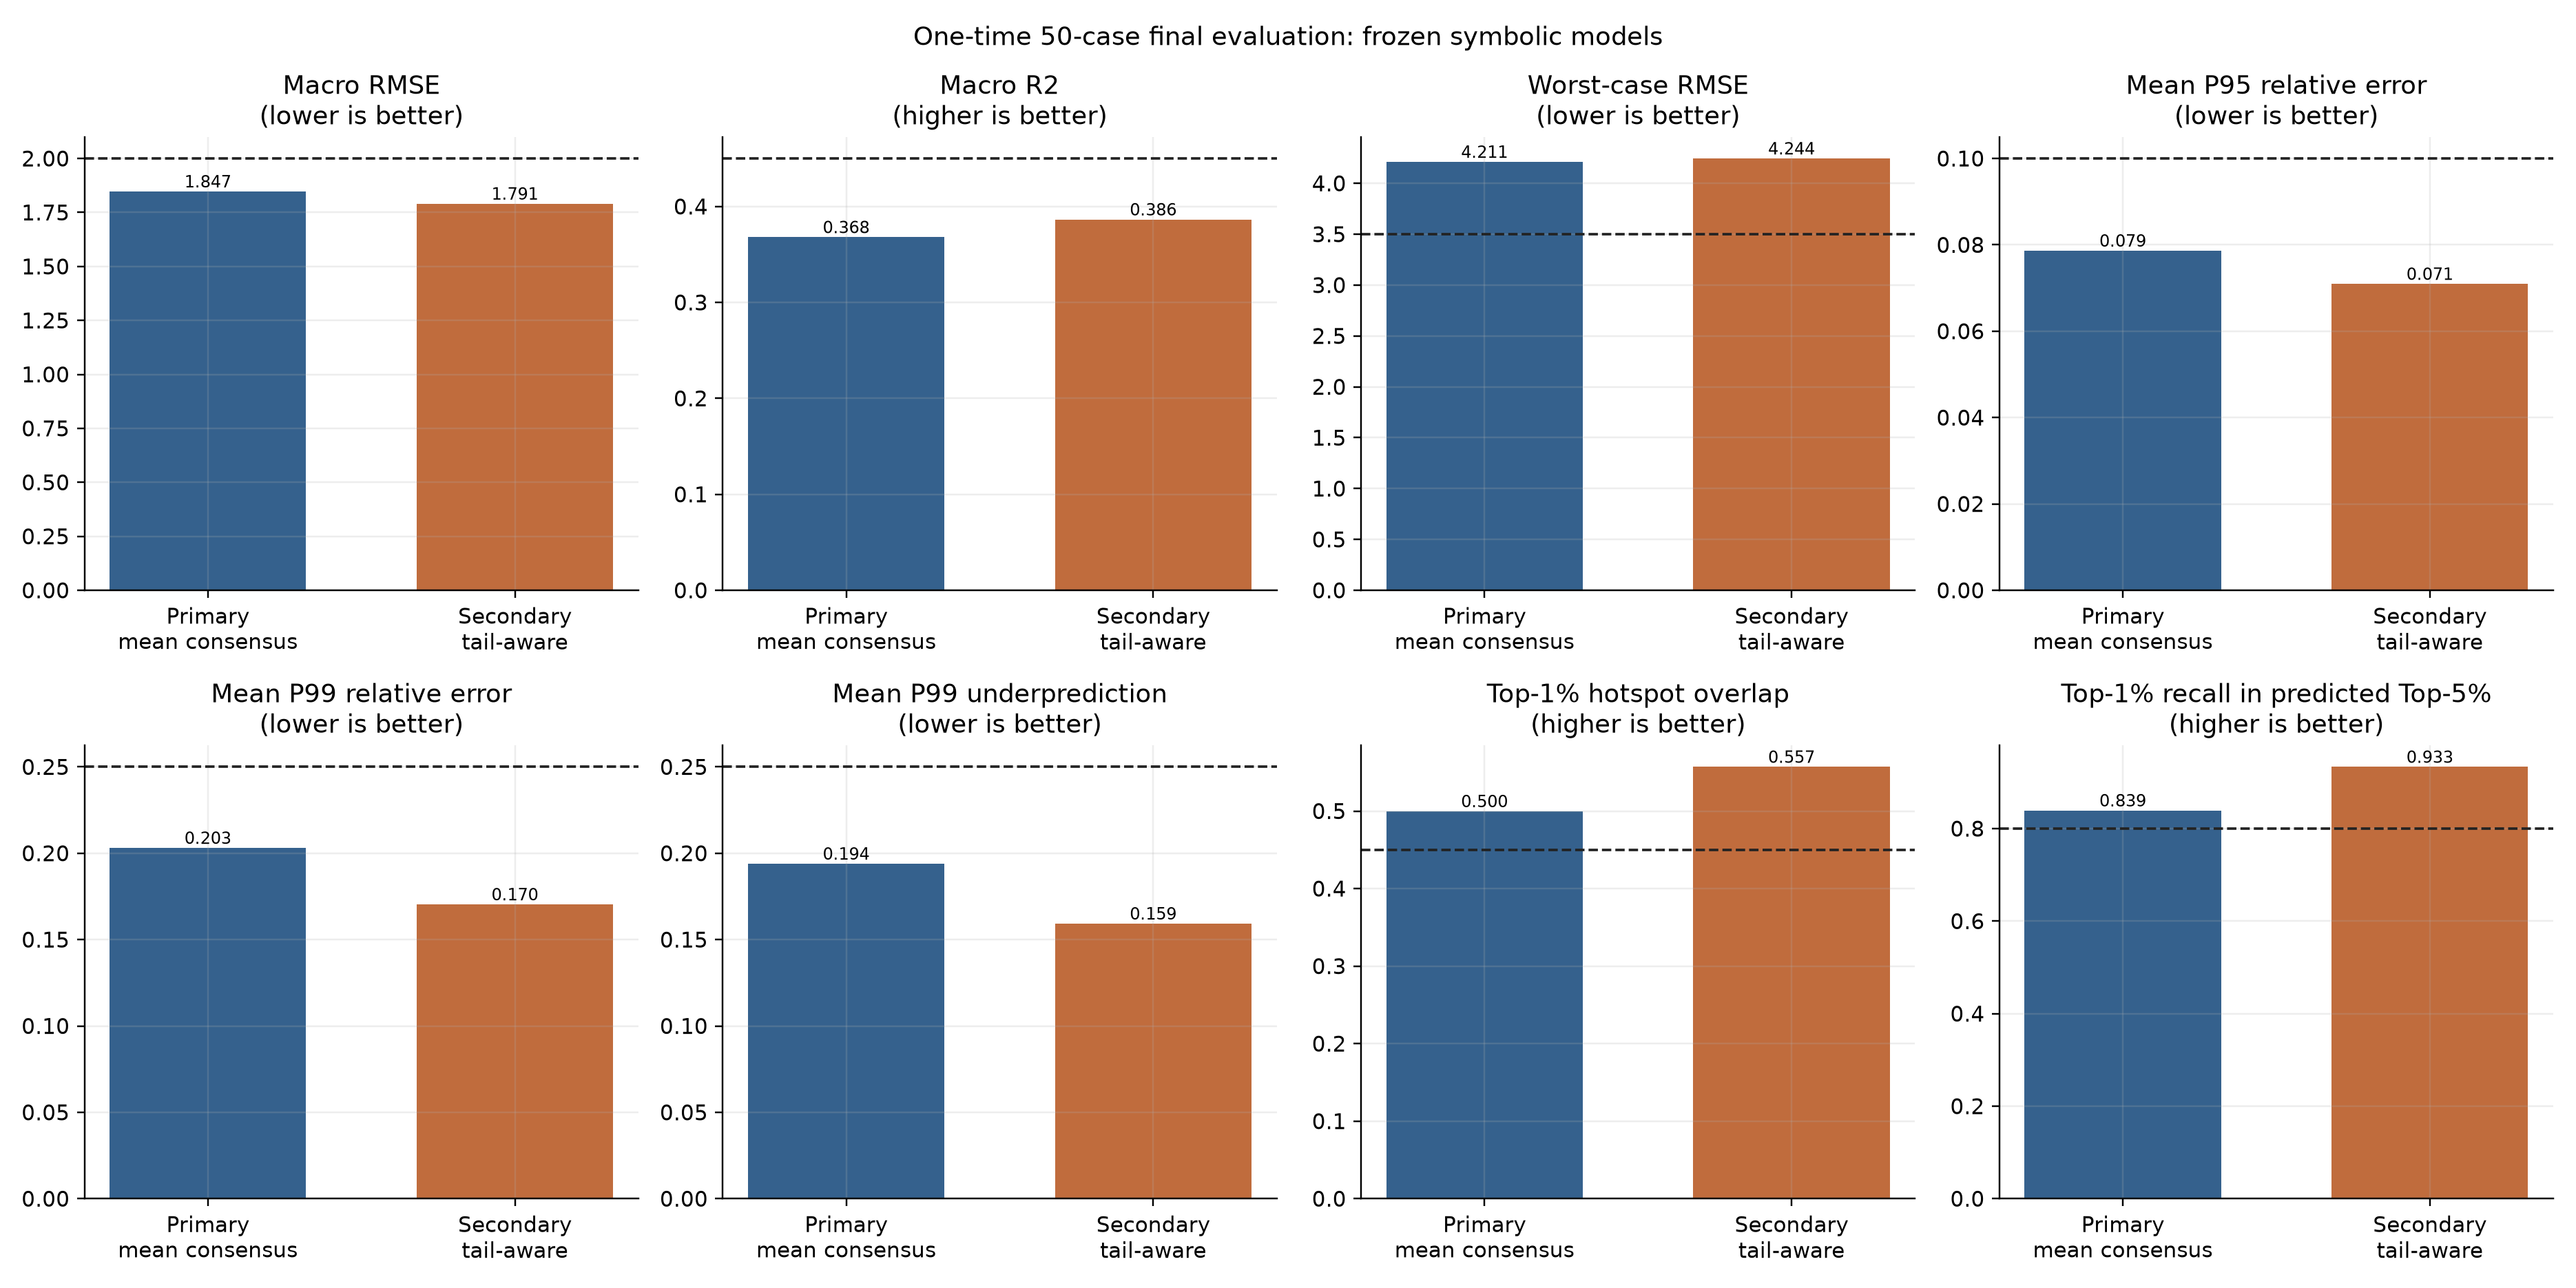


02_final_case_rmse_r2_rankings.png: Case-level stability and difficult-case ranking


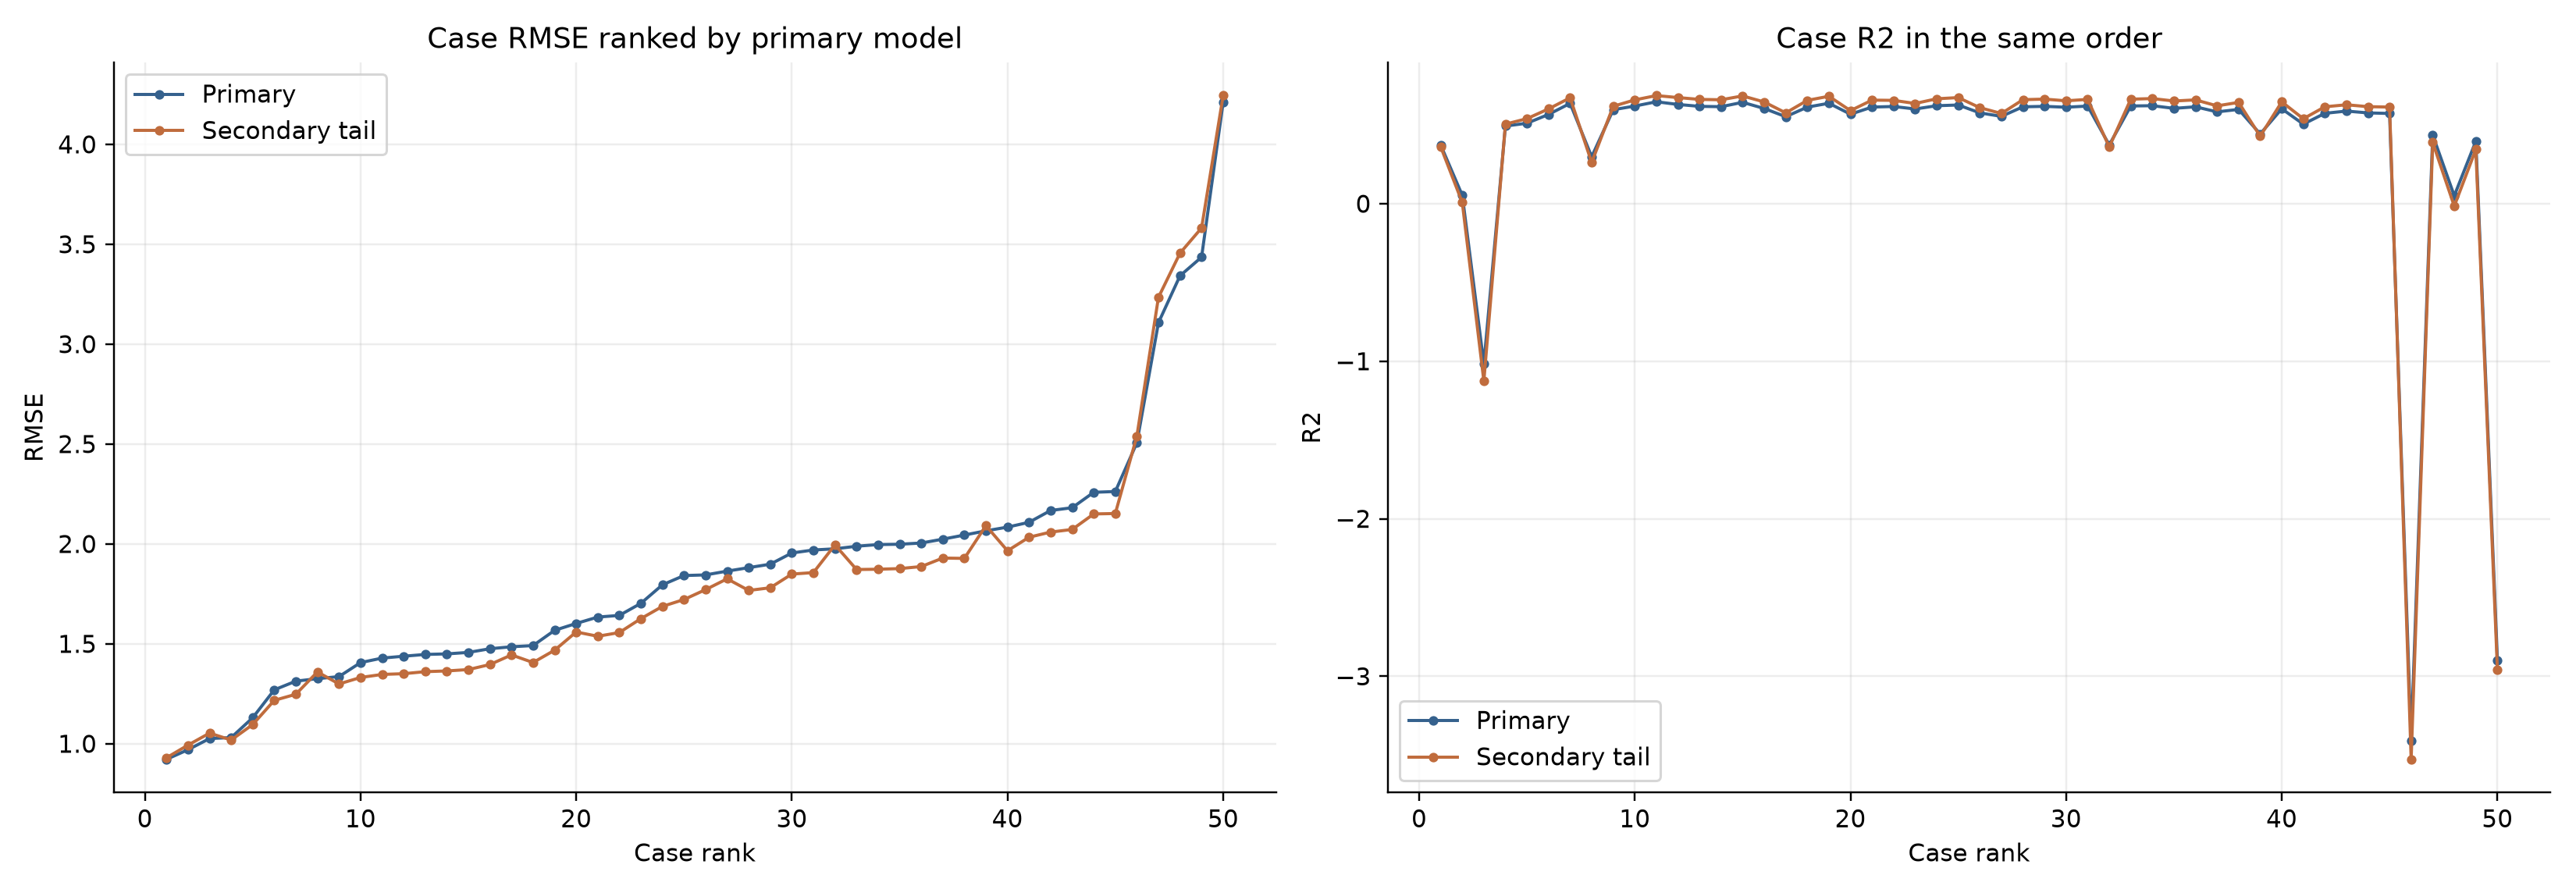


03_final_quantile_calibration.png: P95, P99 and maximum-stress calibration


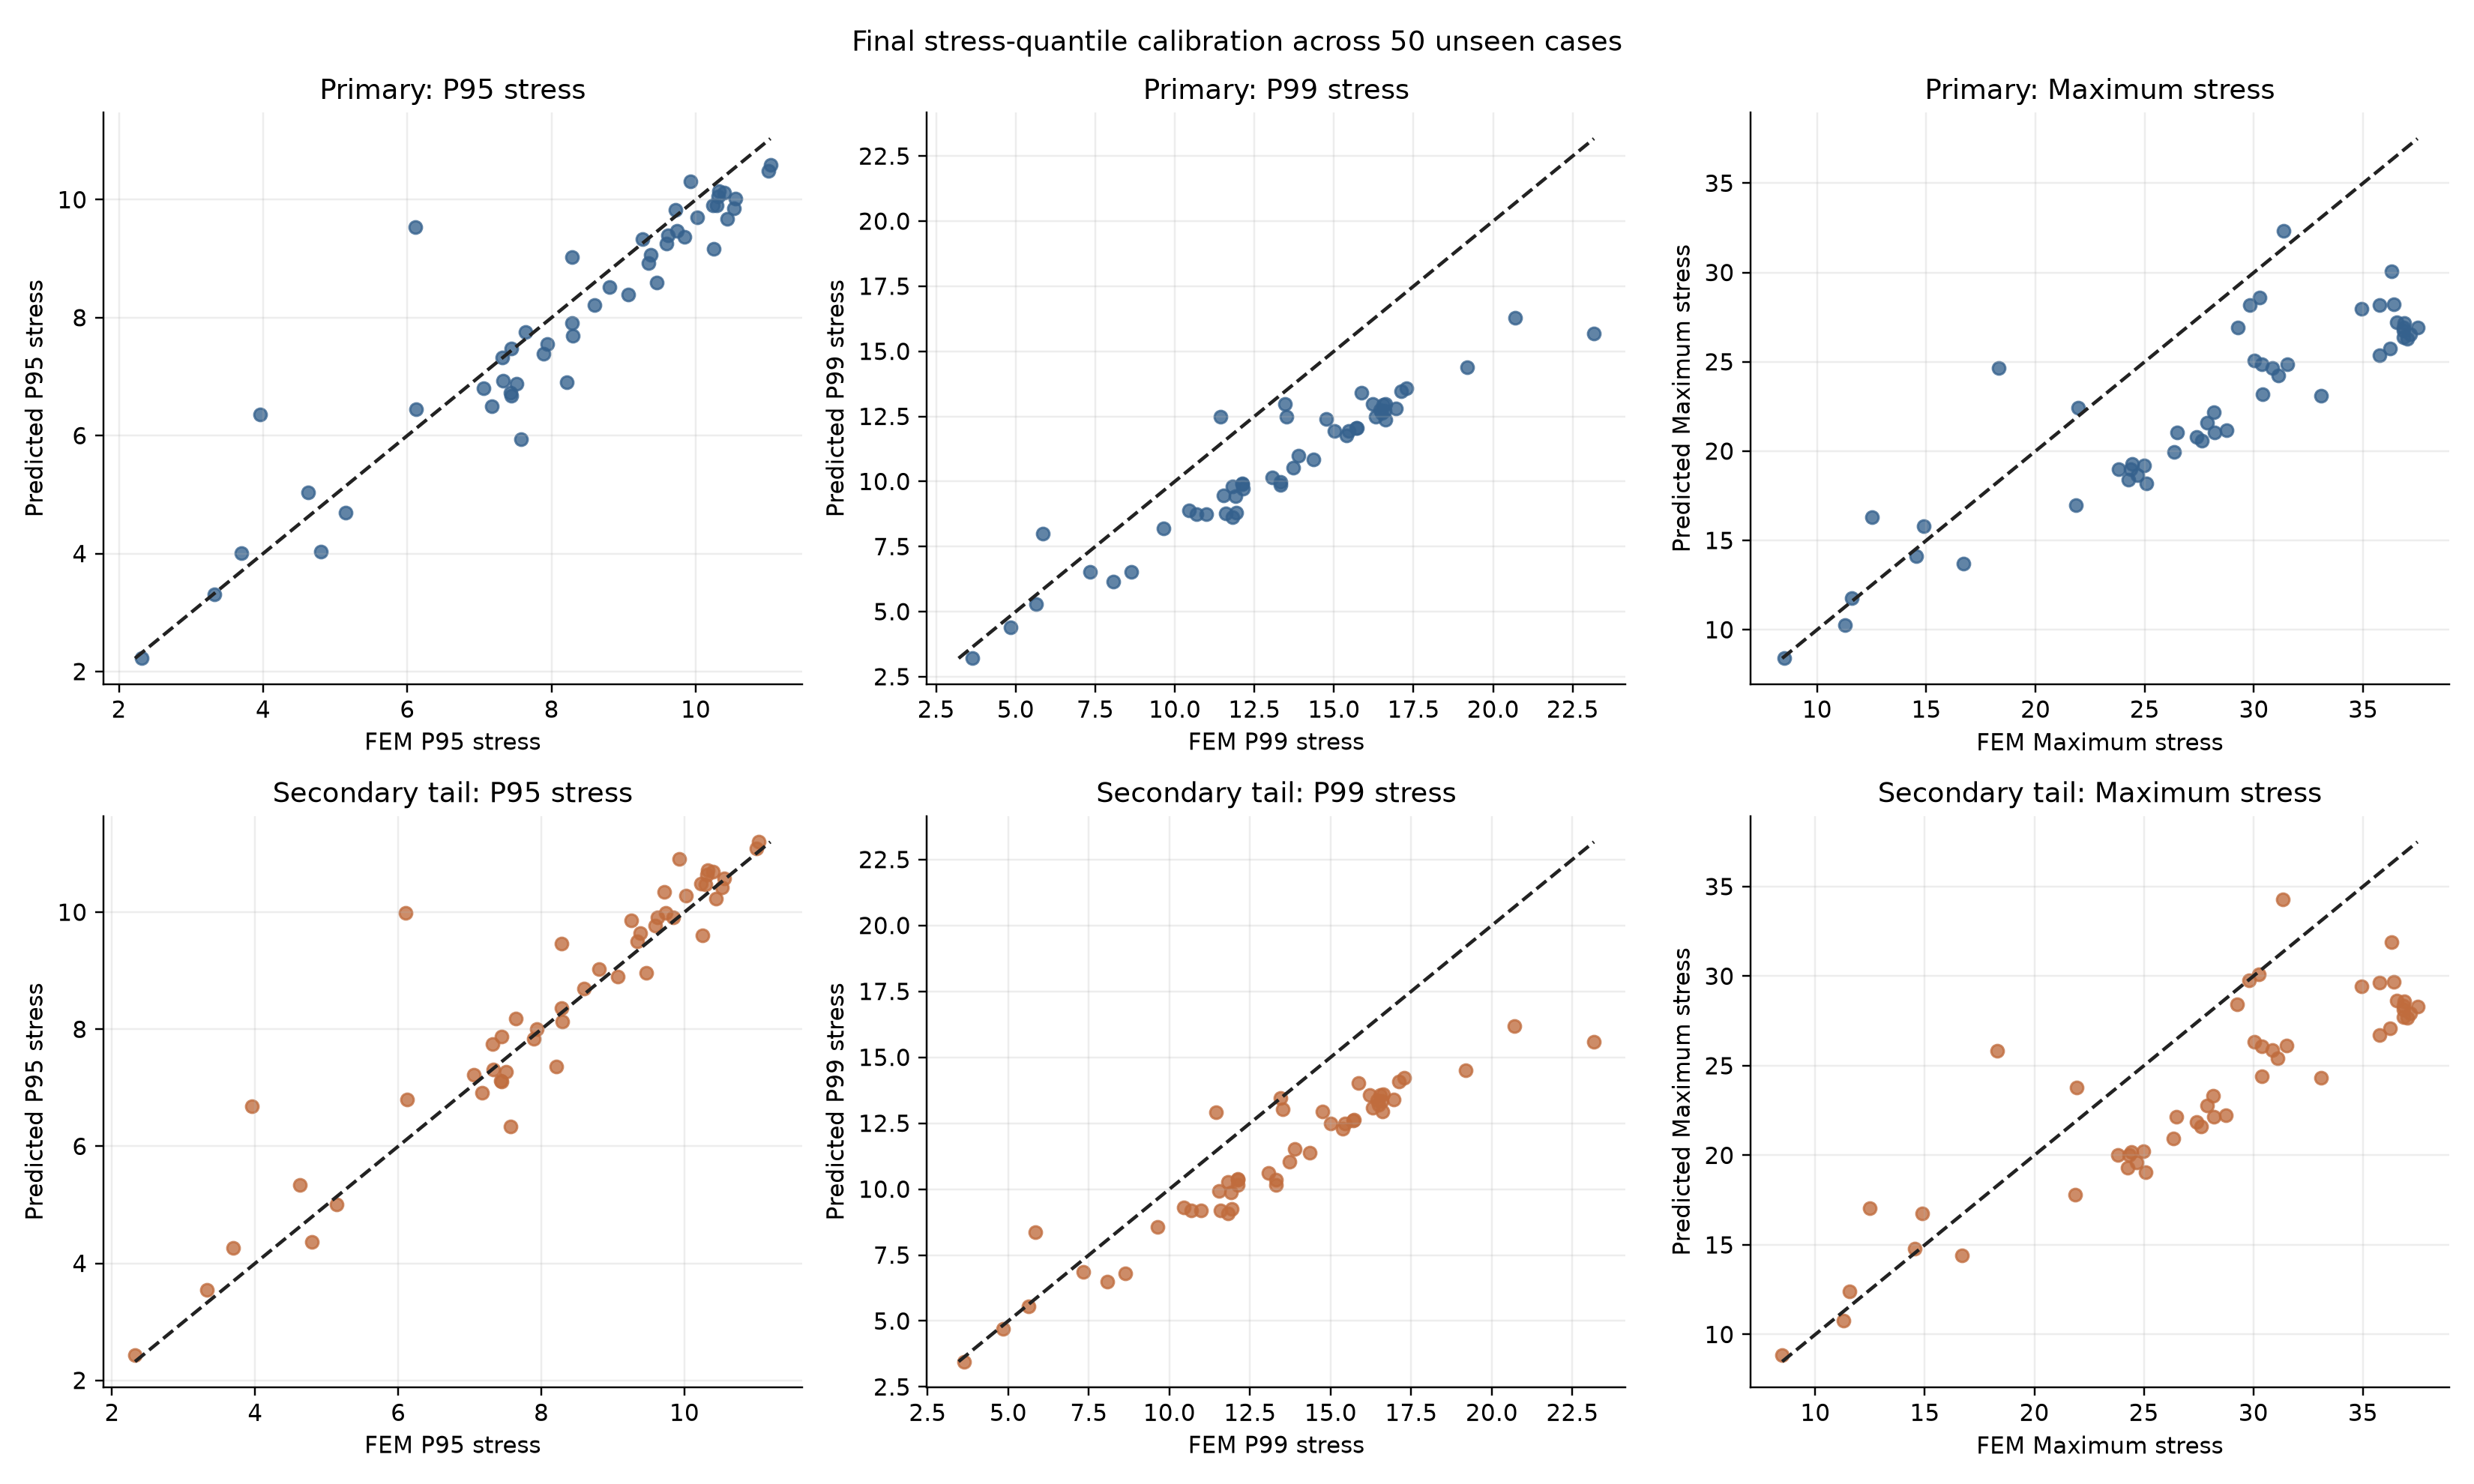


04_final_tail_hotspot_case_metrics.png: Per-case P99 error and hotspot overlap


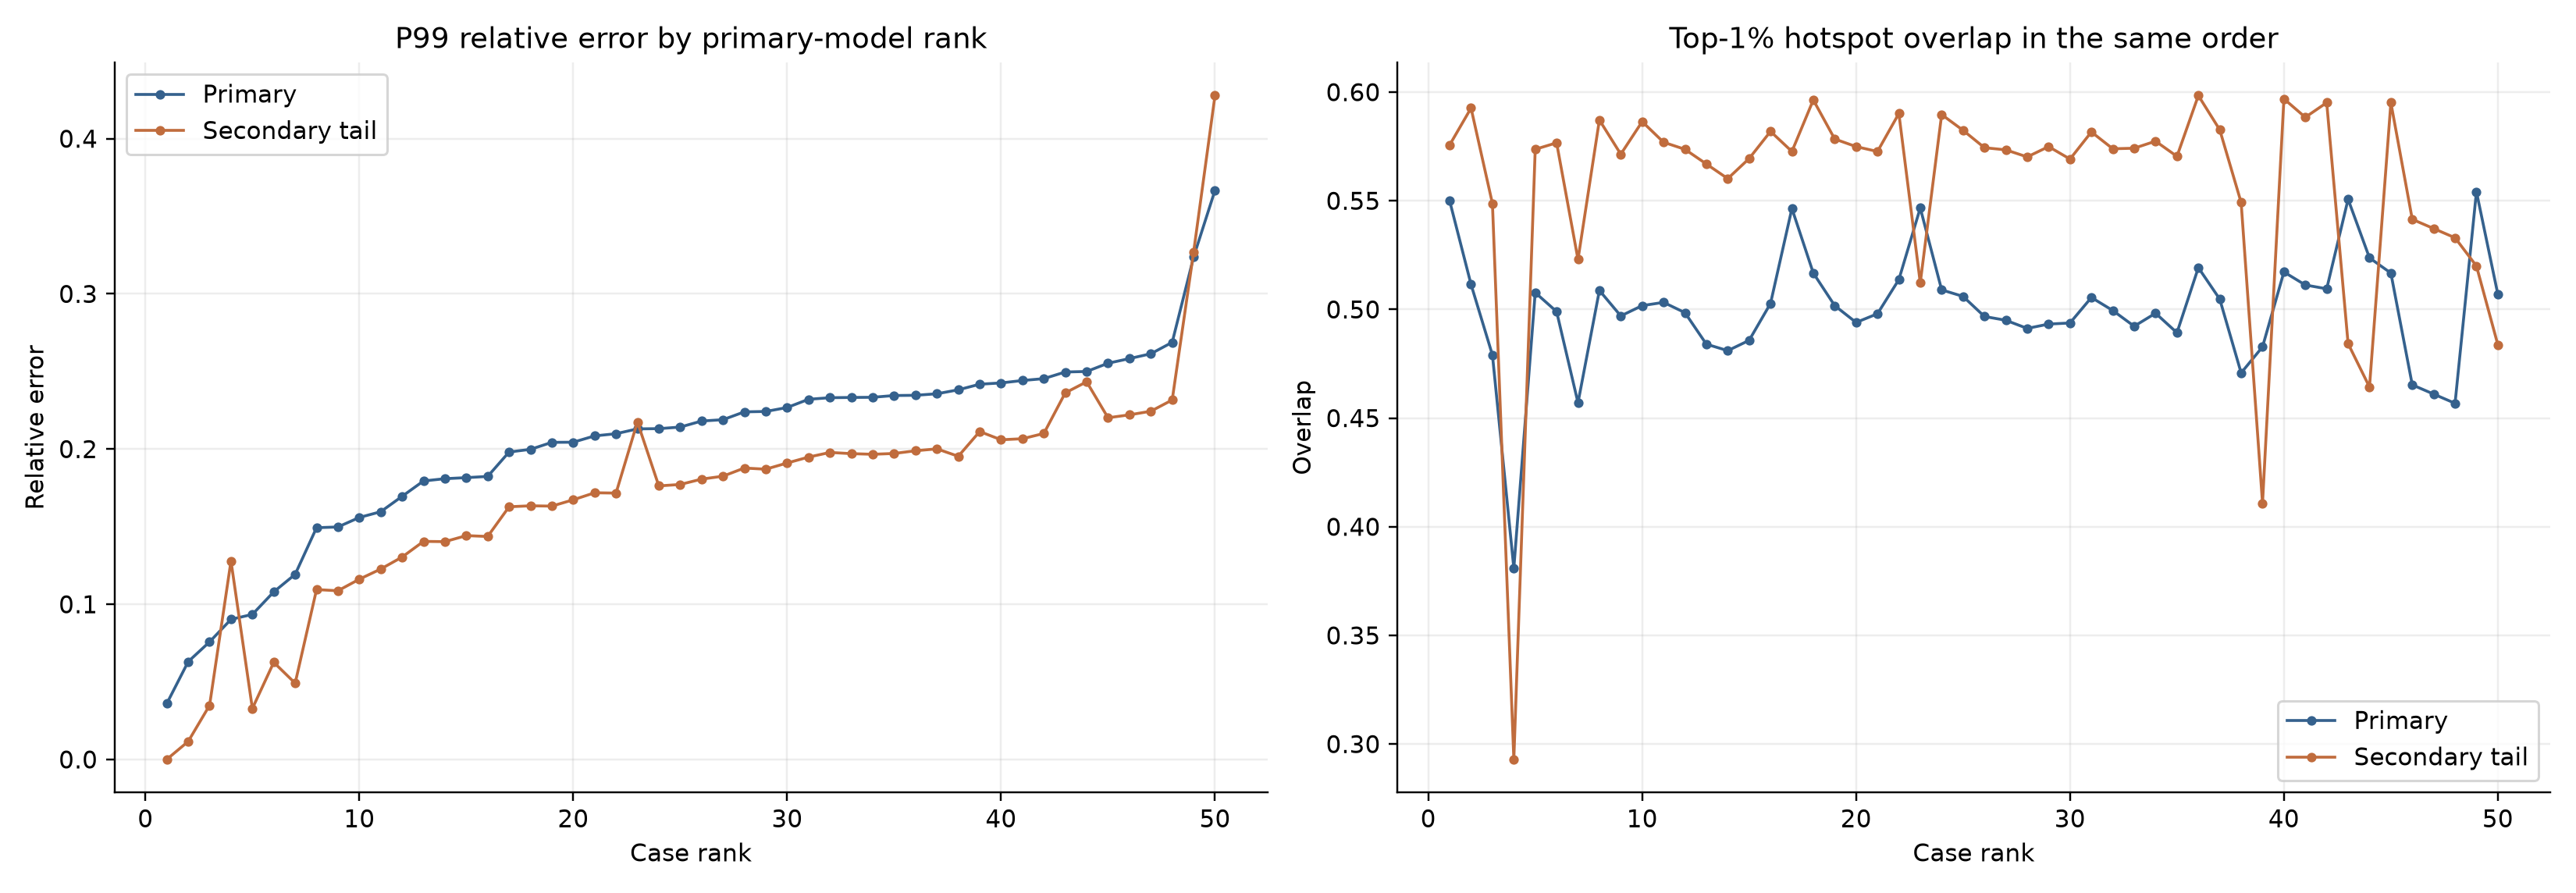


05_final_residual_diagnostics.png: Global prediction and residual density


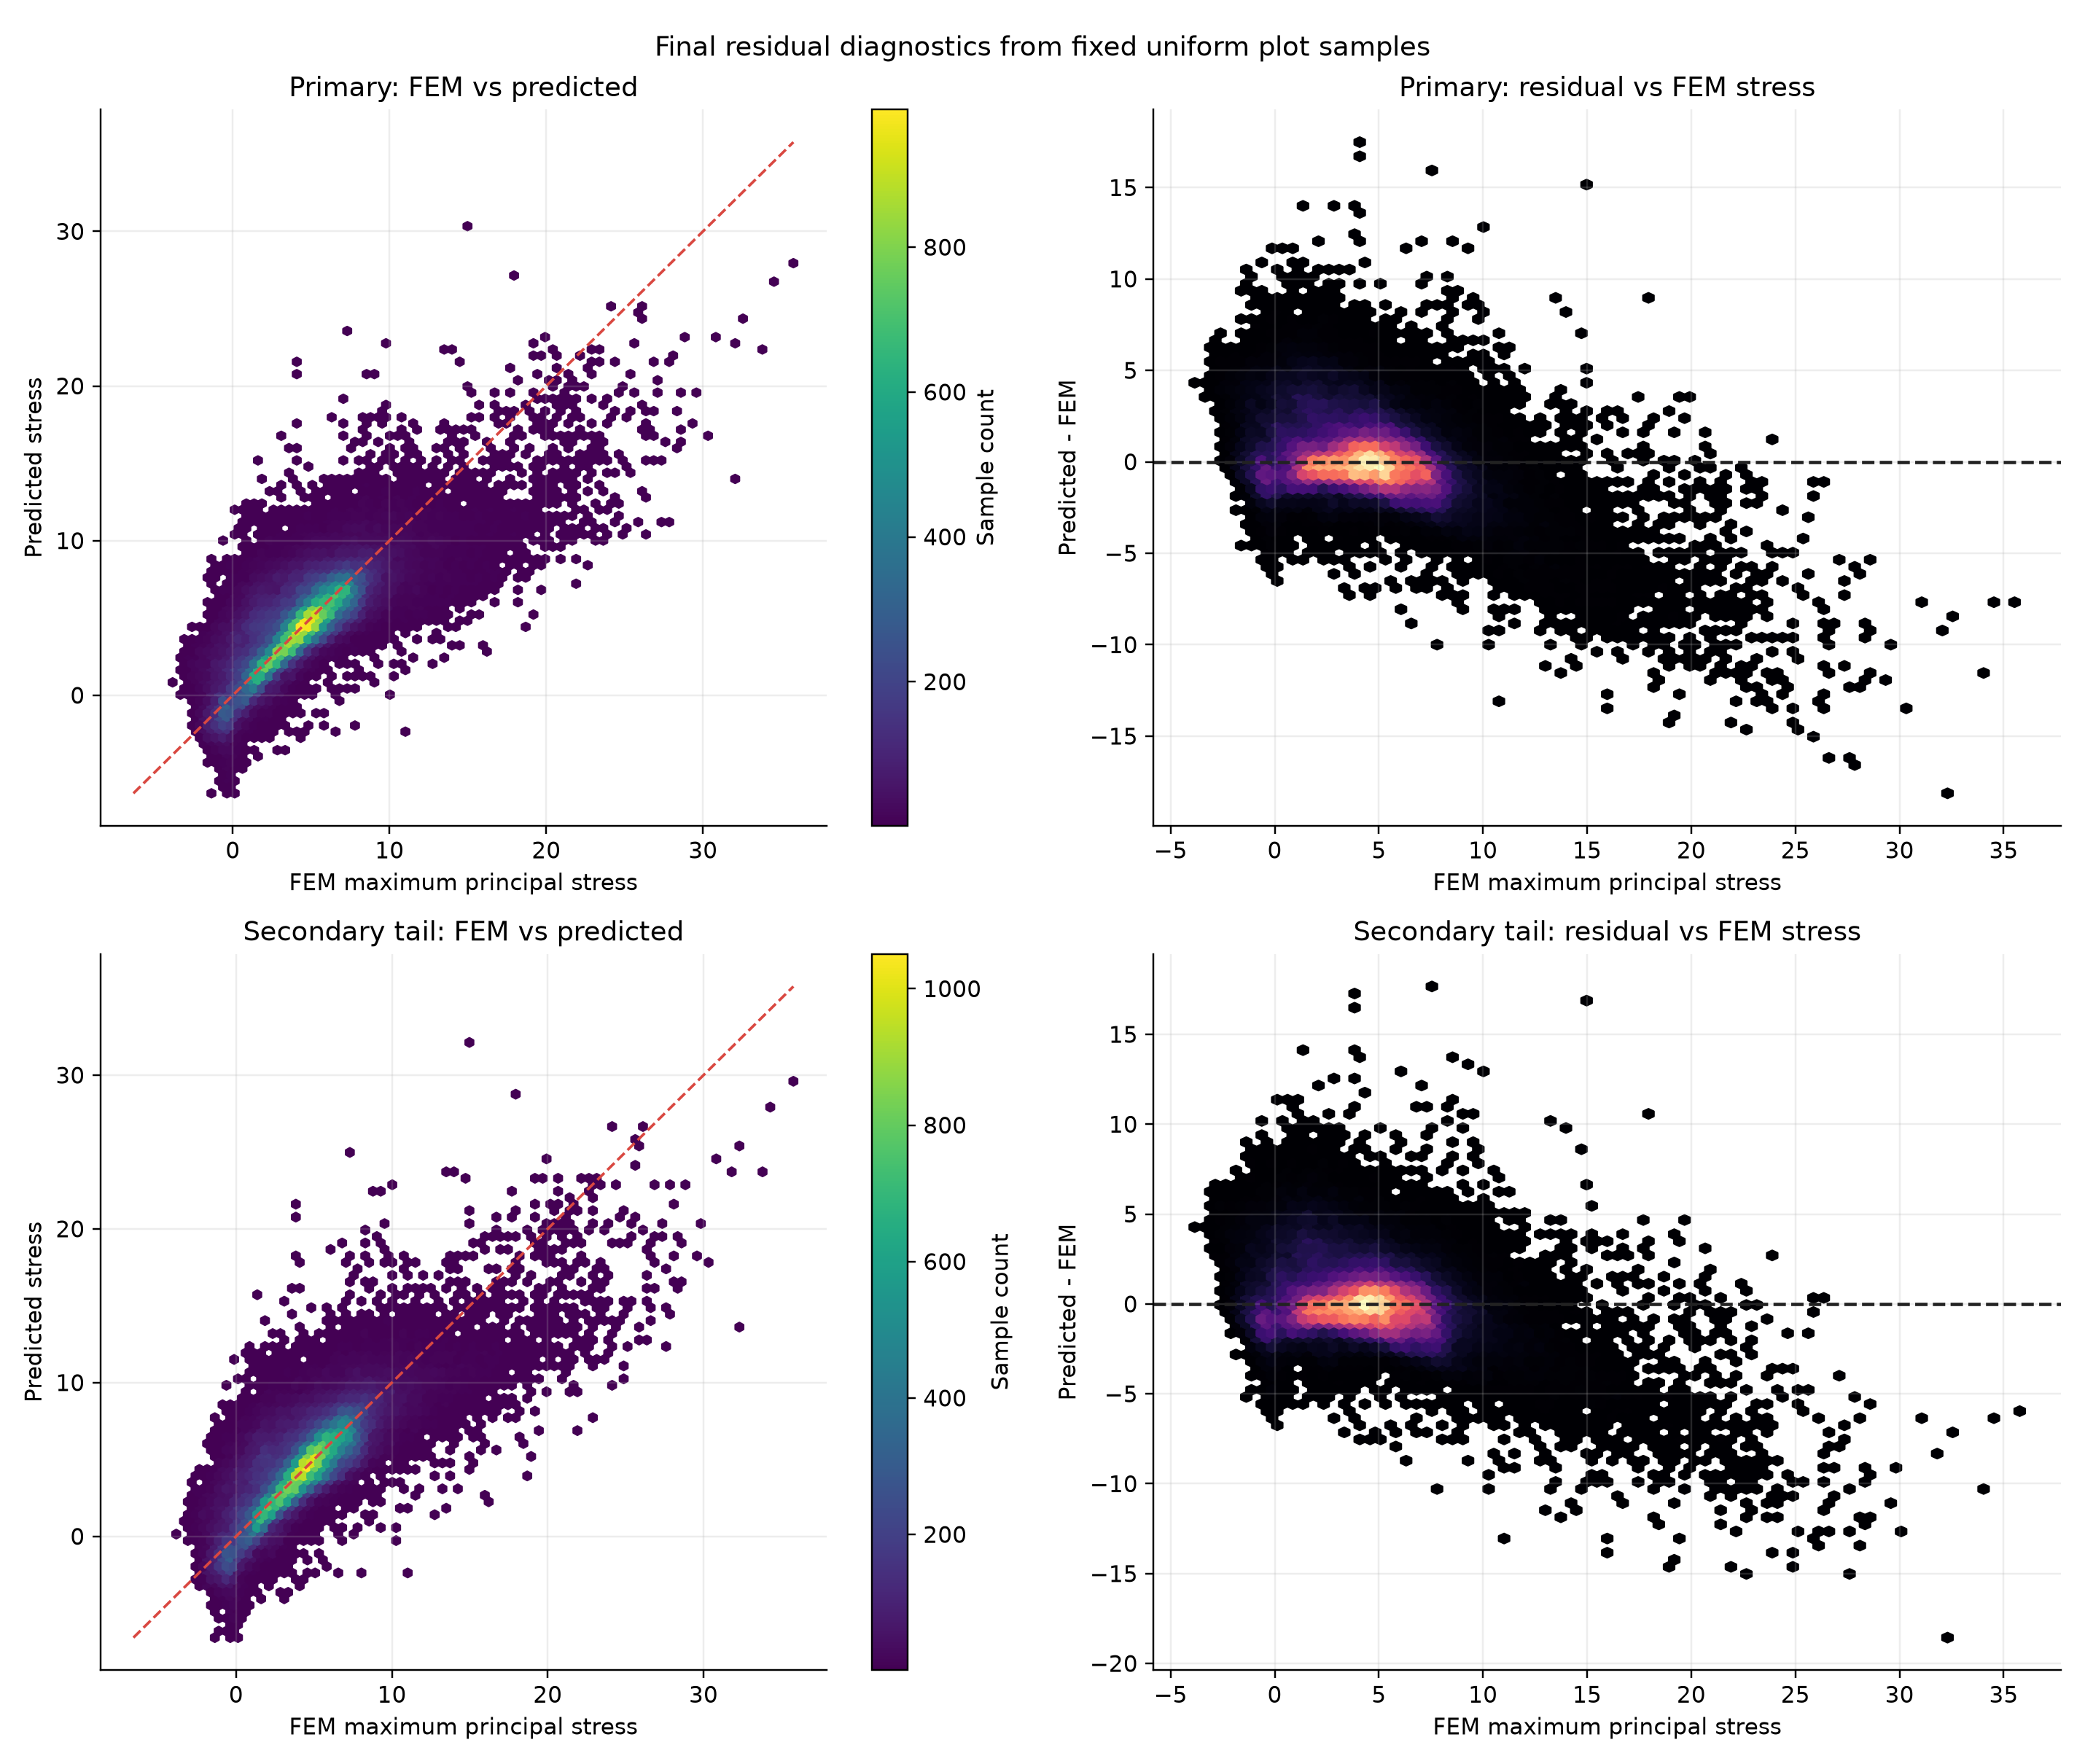


06_development_to_final_comparison.png: Development-to-final generalisation shift


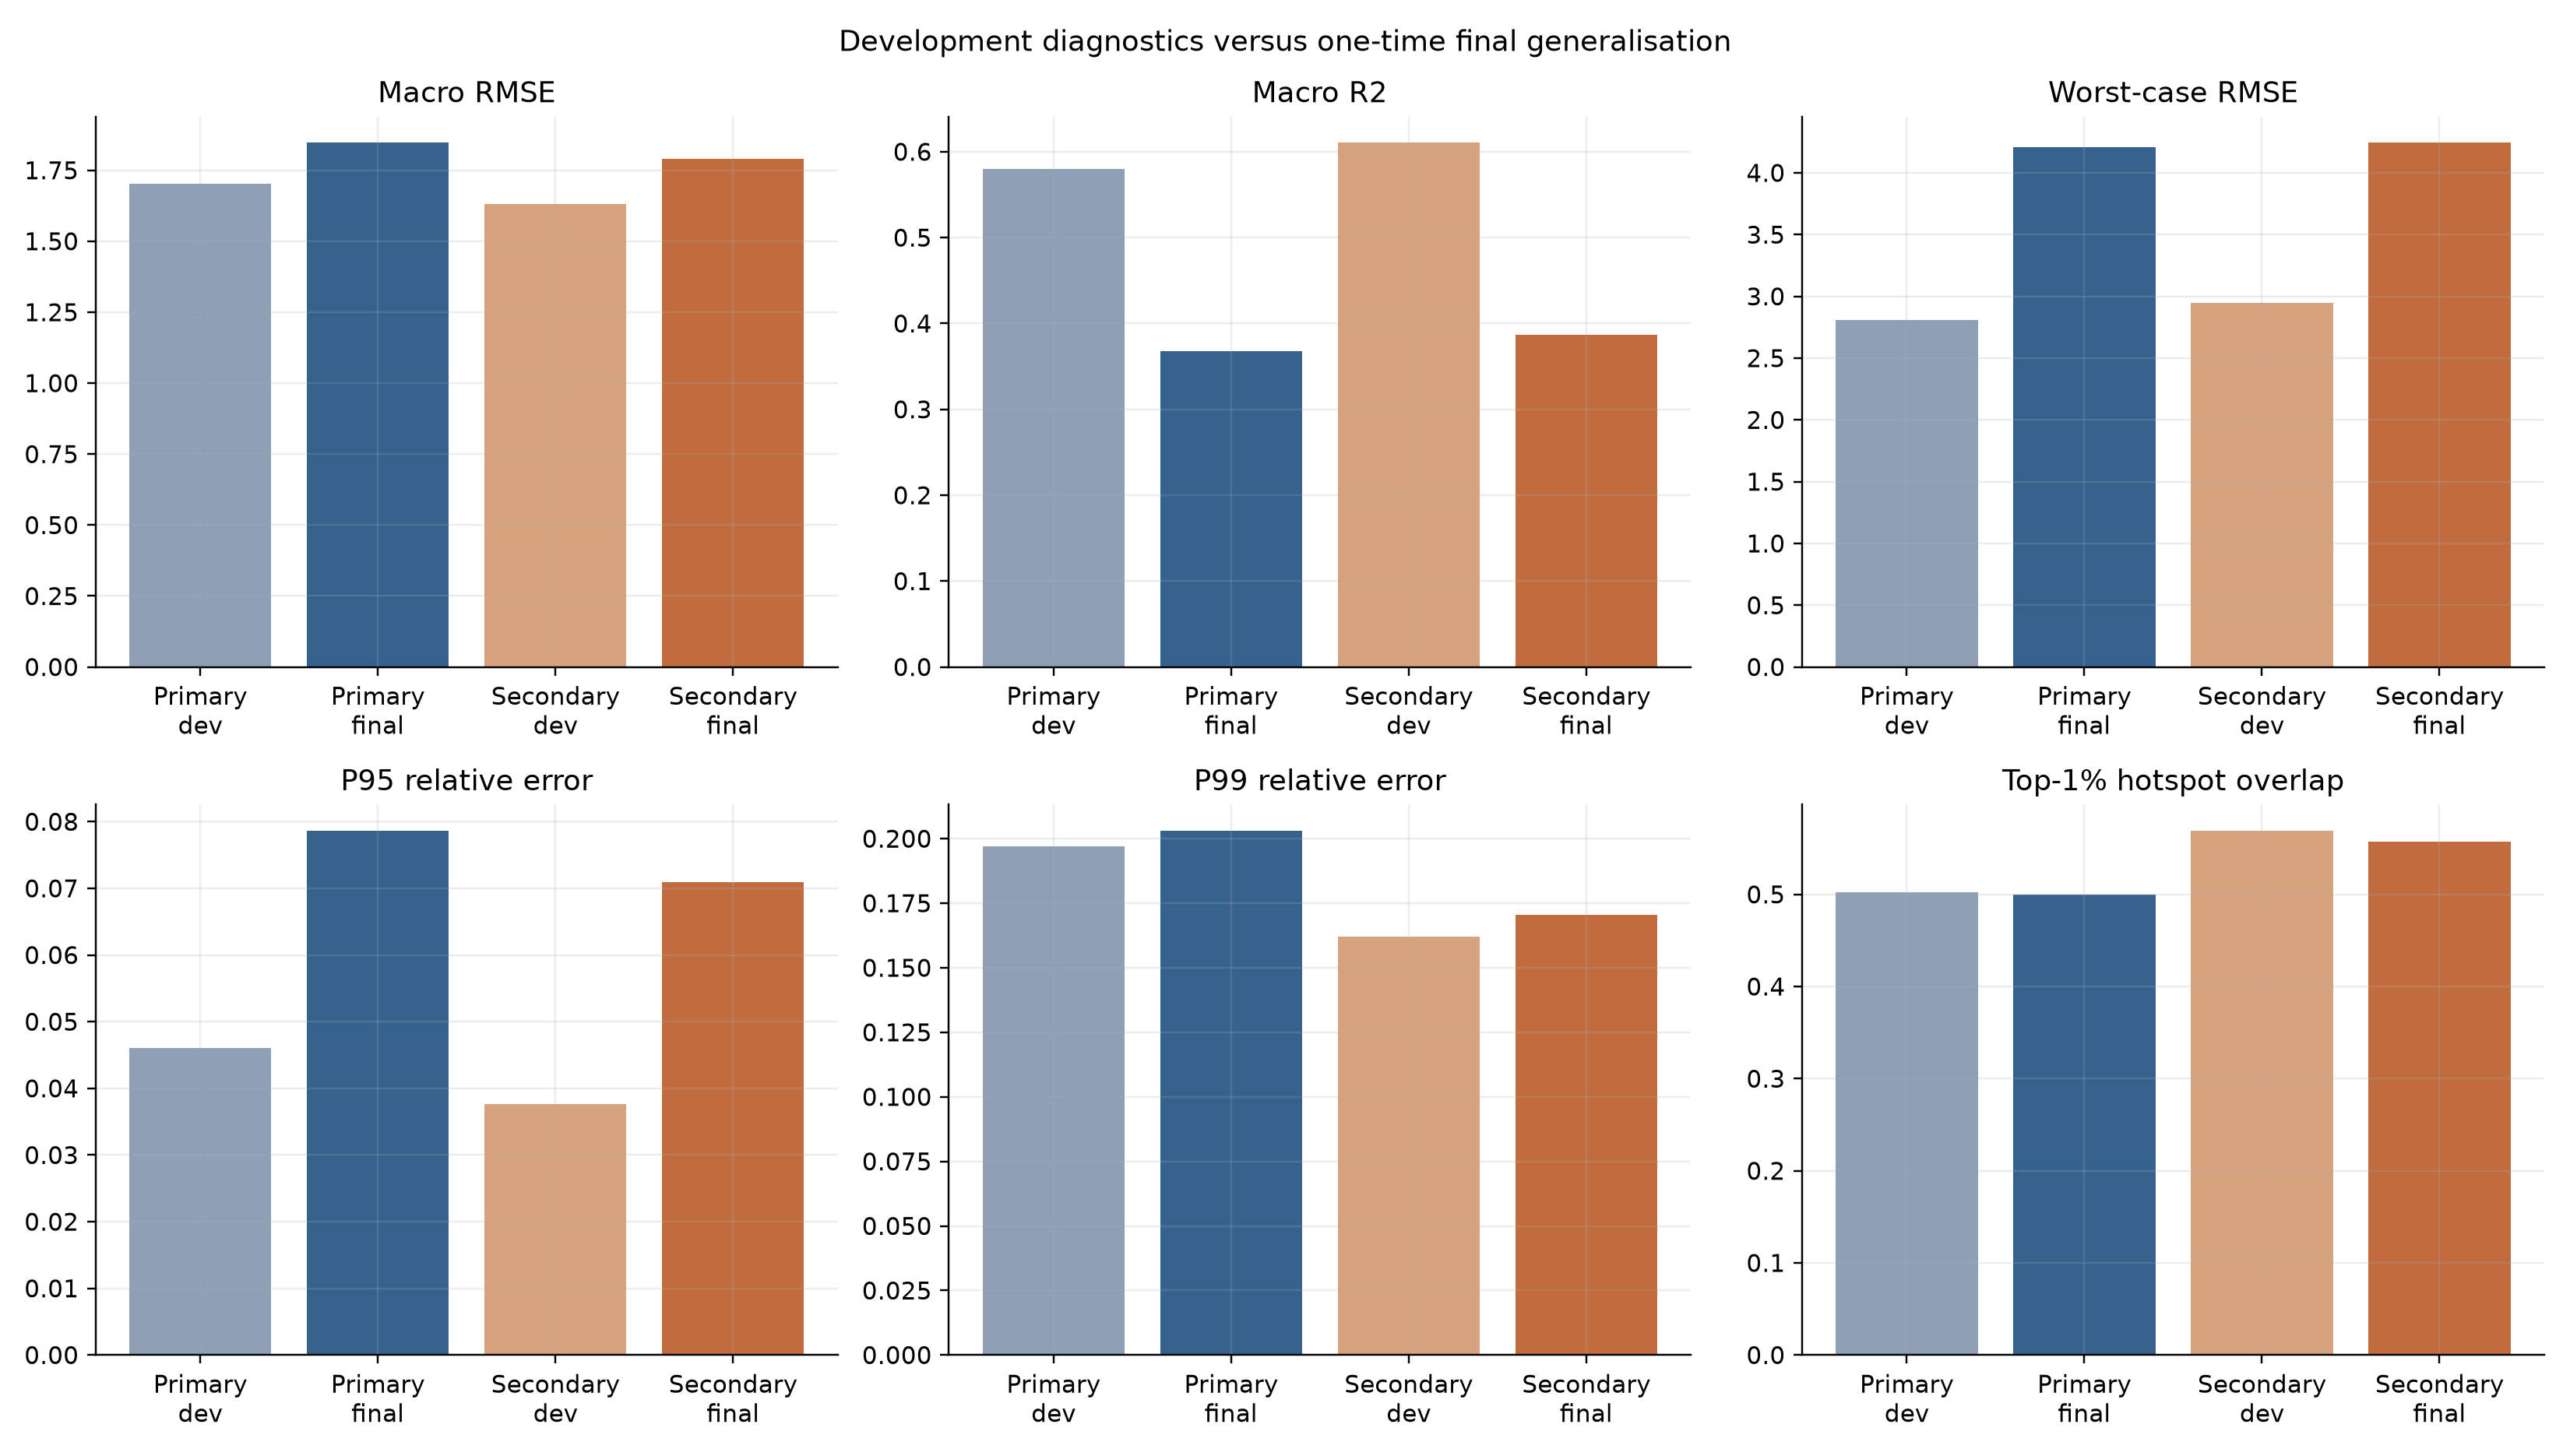


07_best_case_spatial_stress_and_residual.png: Spatial FEM/prediction/residual comparison for the best primary-RMSE case


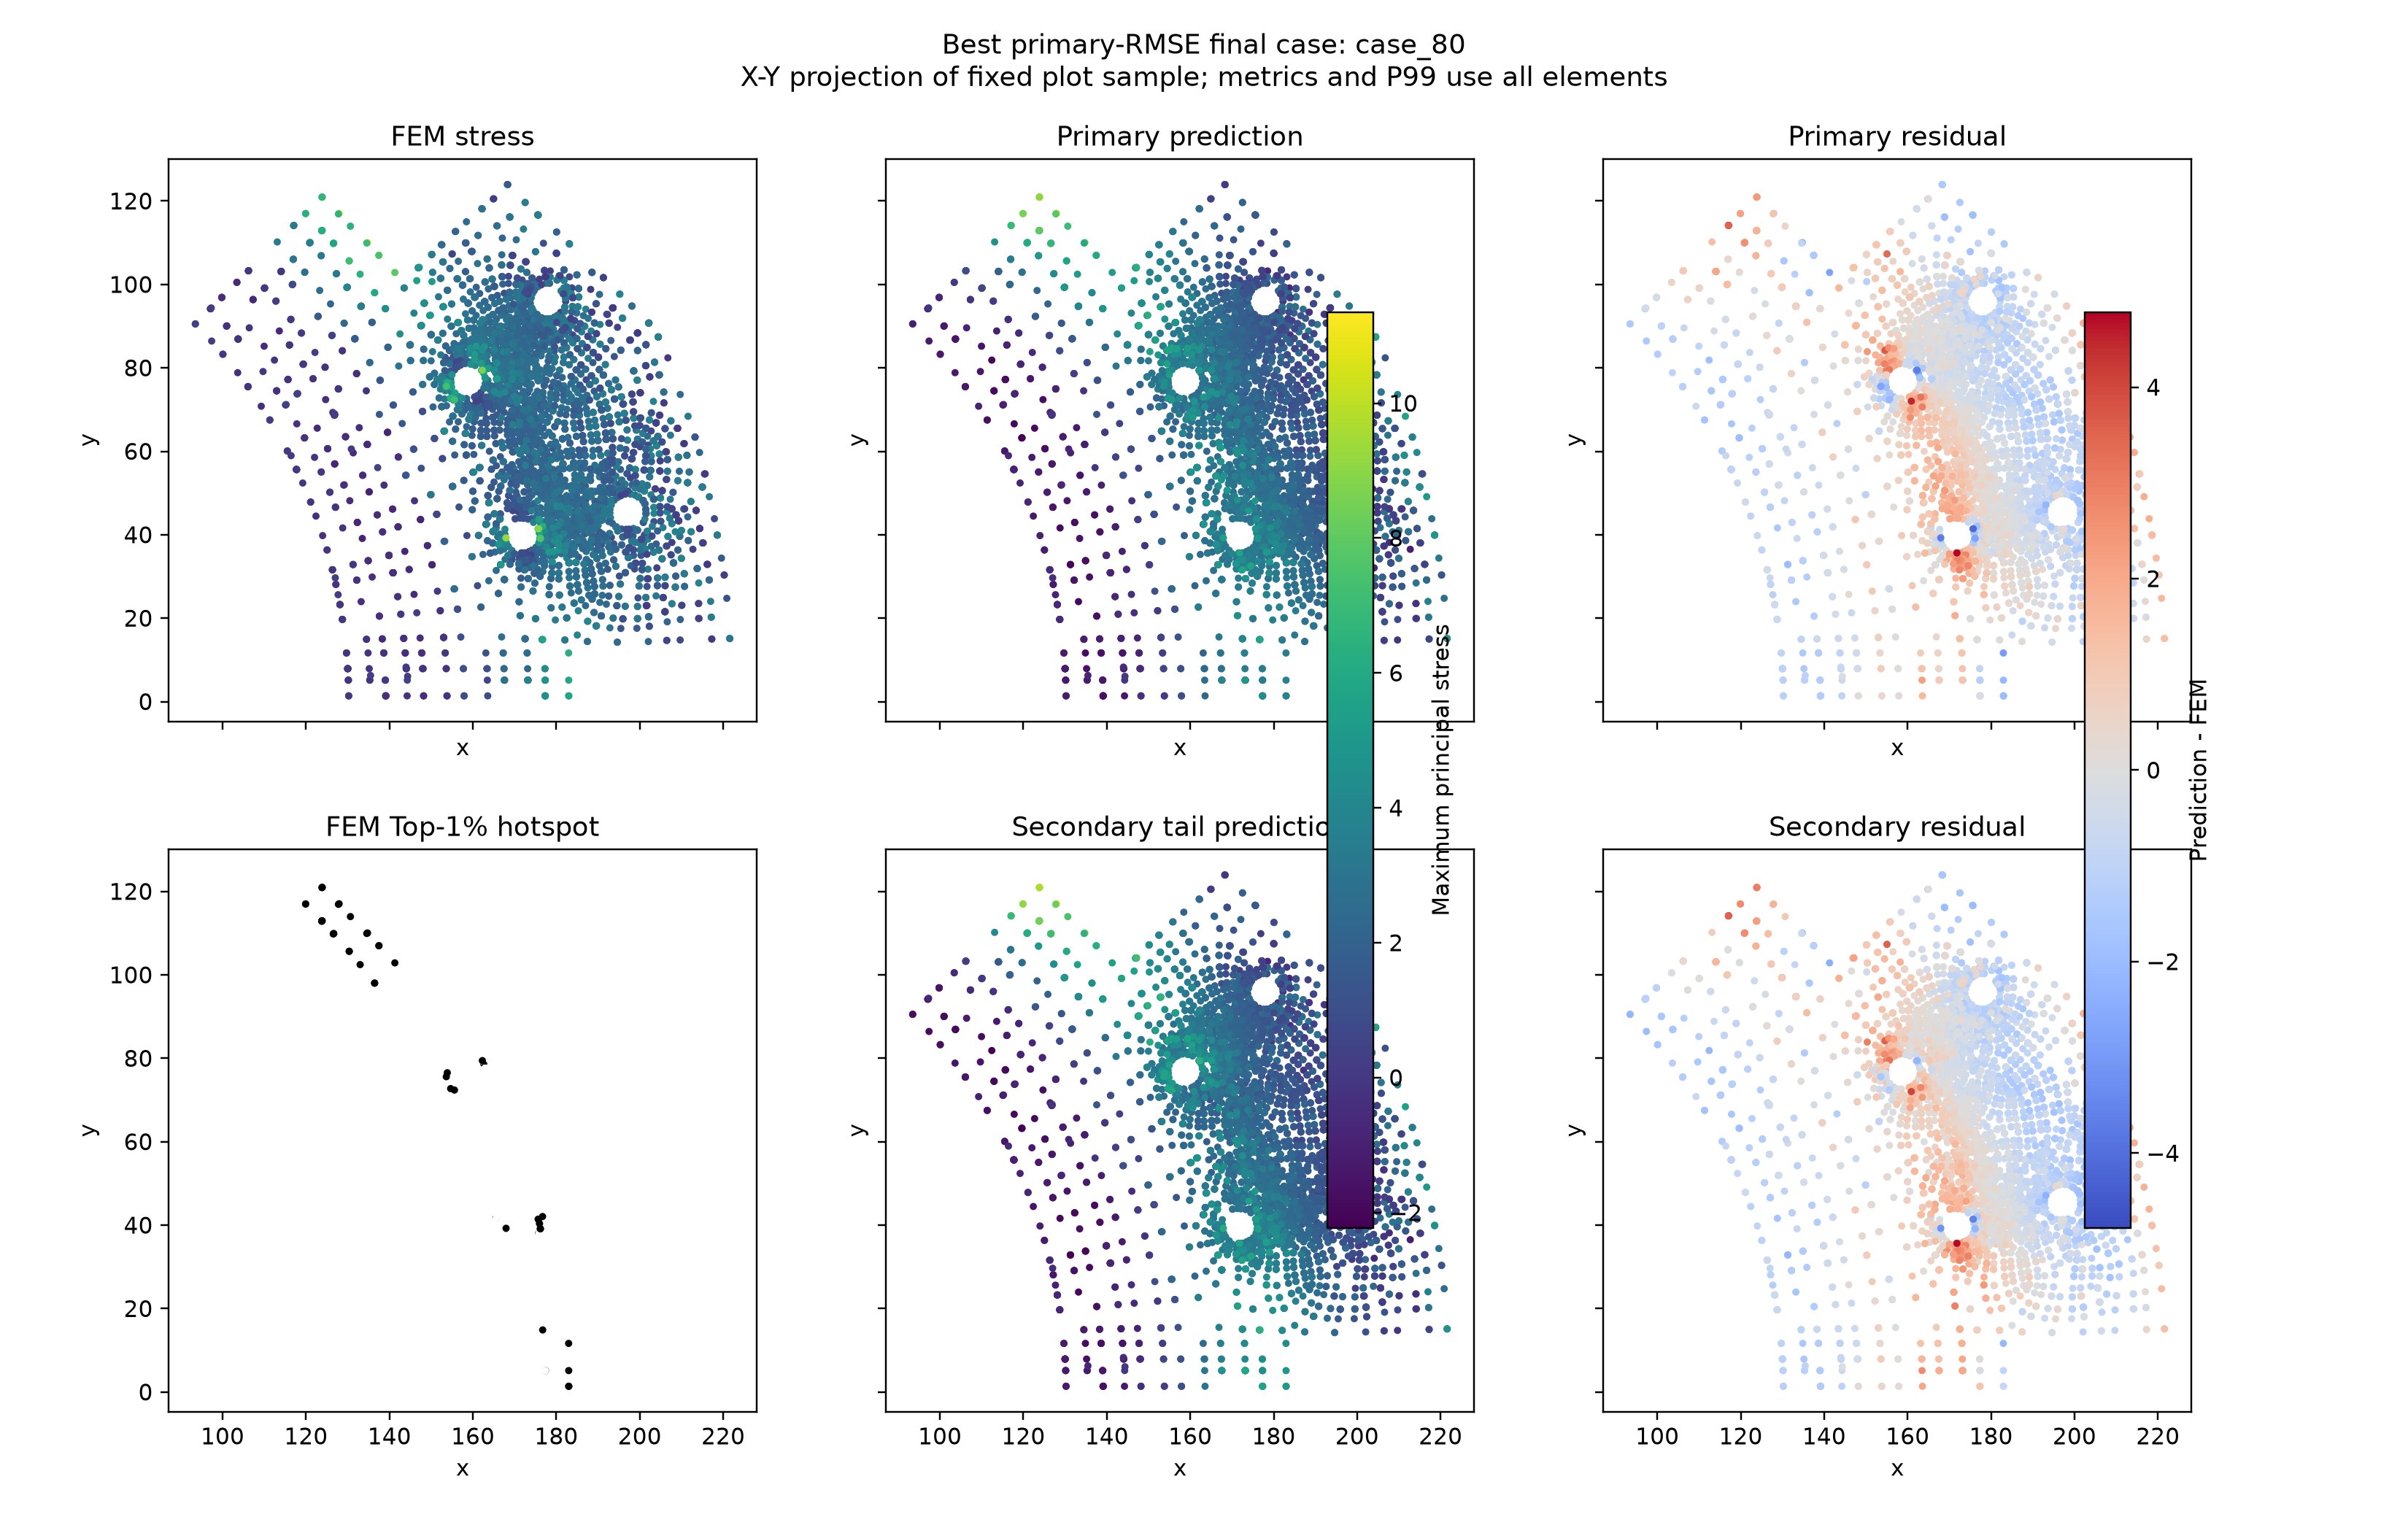


07_median_case_spatial_stress_and_residual.png: Spatial FEM/prediction/residual comparison for the median primary-RMSE case

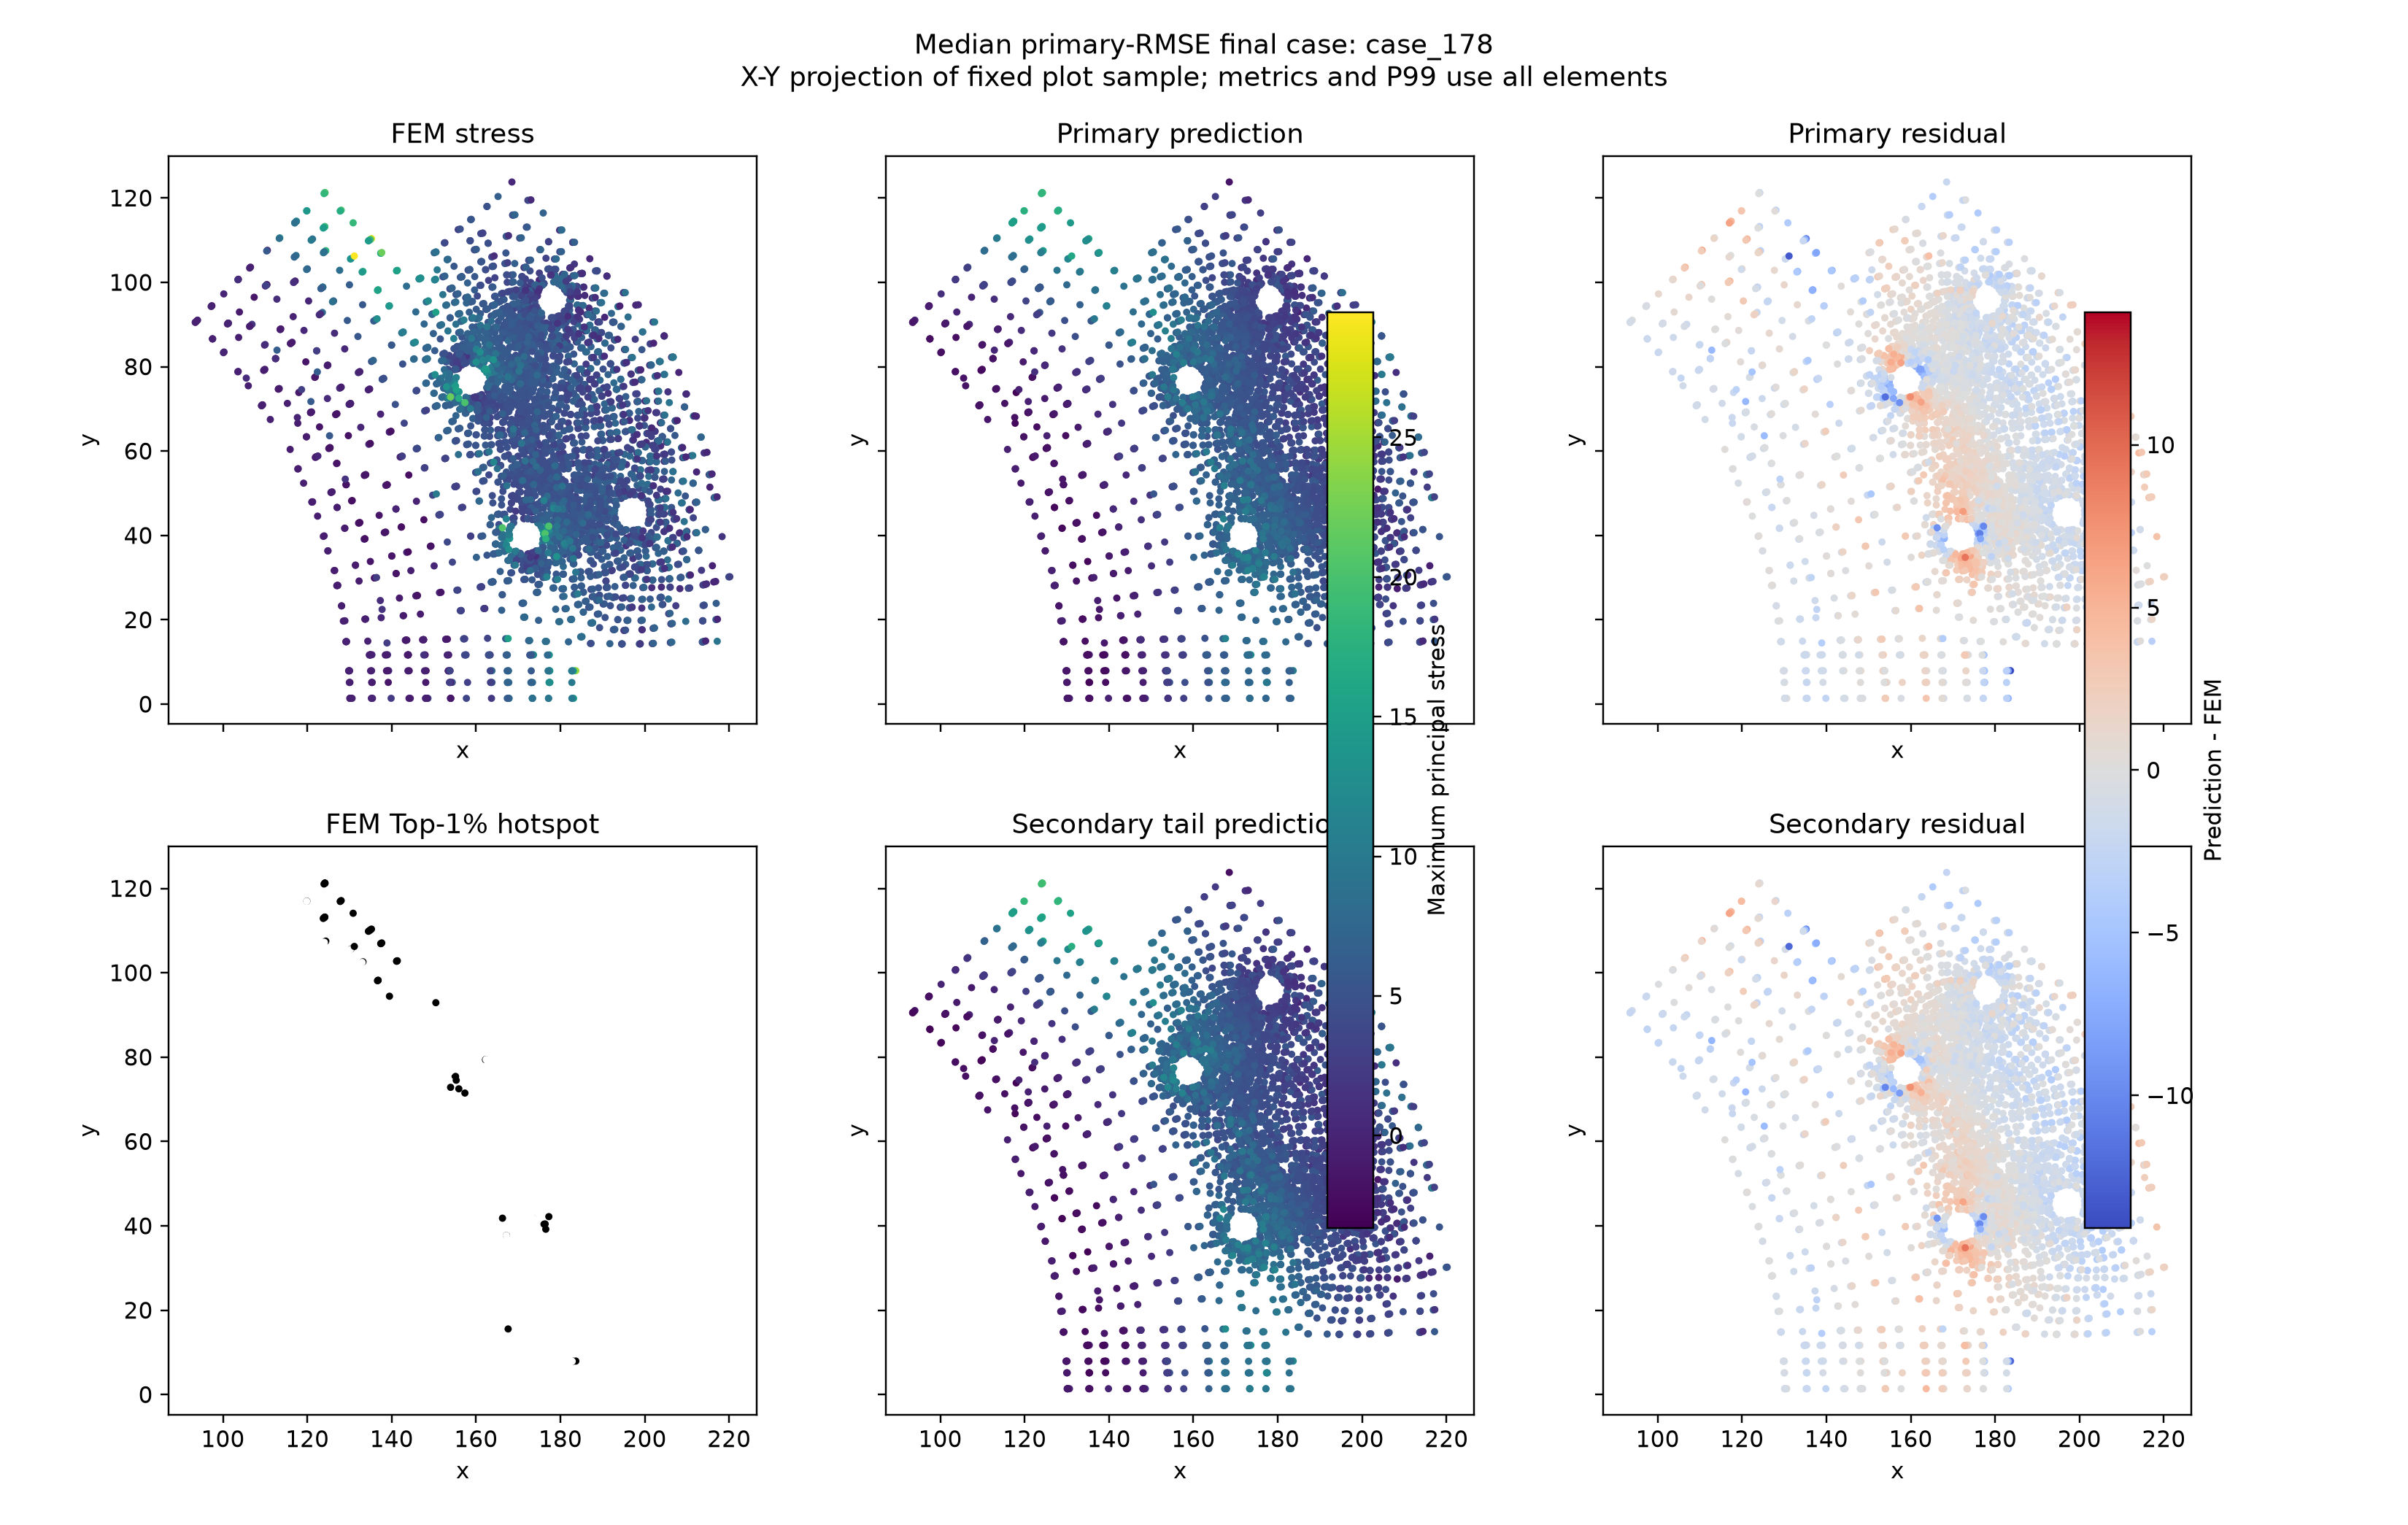


07_worst_case_spatial_stress_and_residual.png: Spatial FEM/prediction/residual comparison for the worst primary-RMSE case


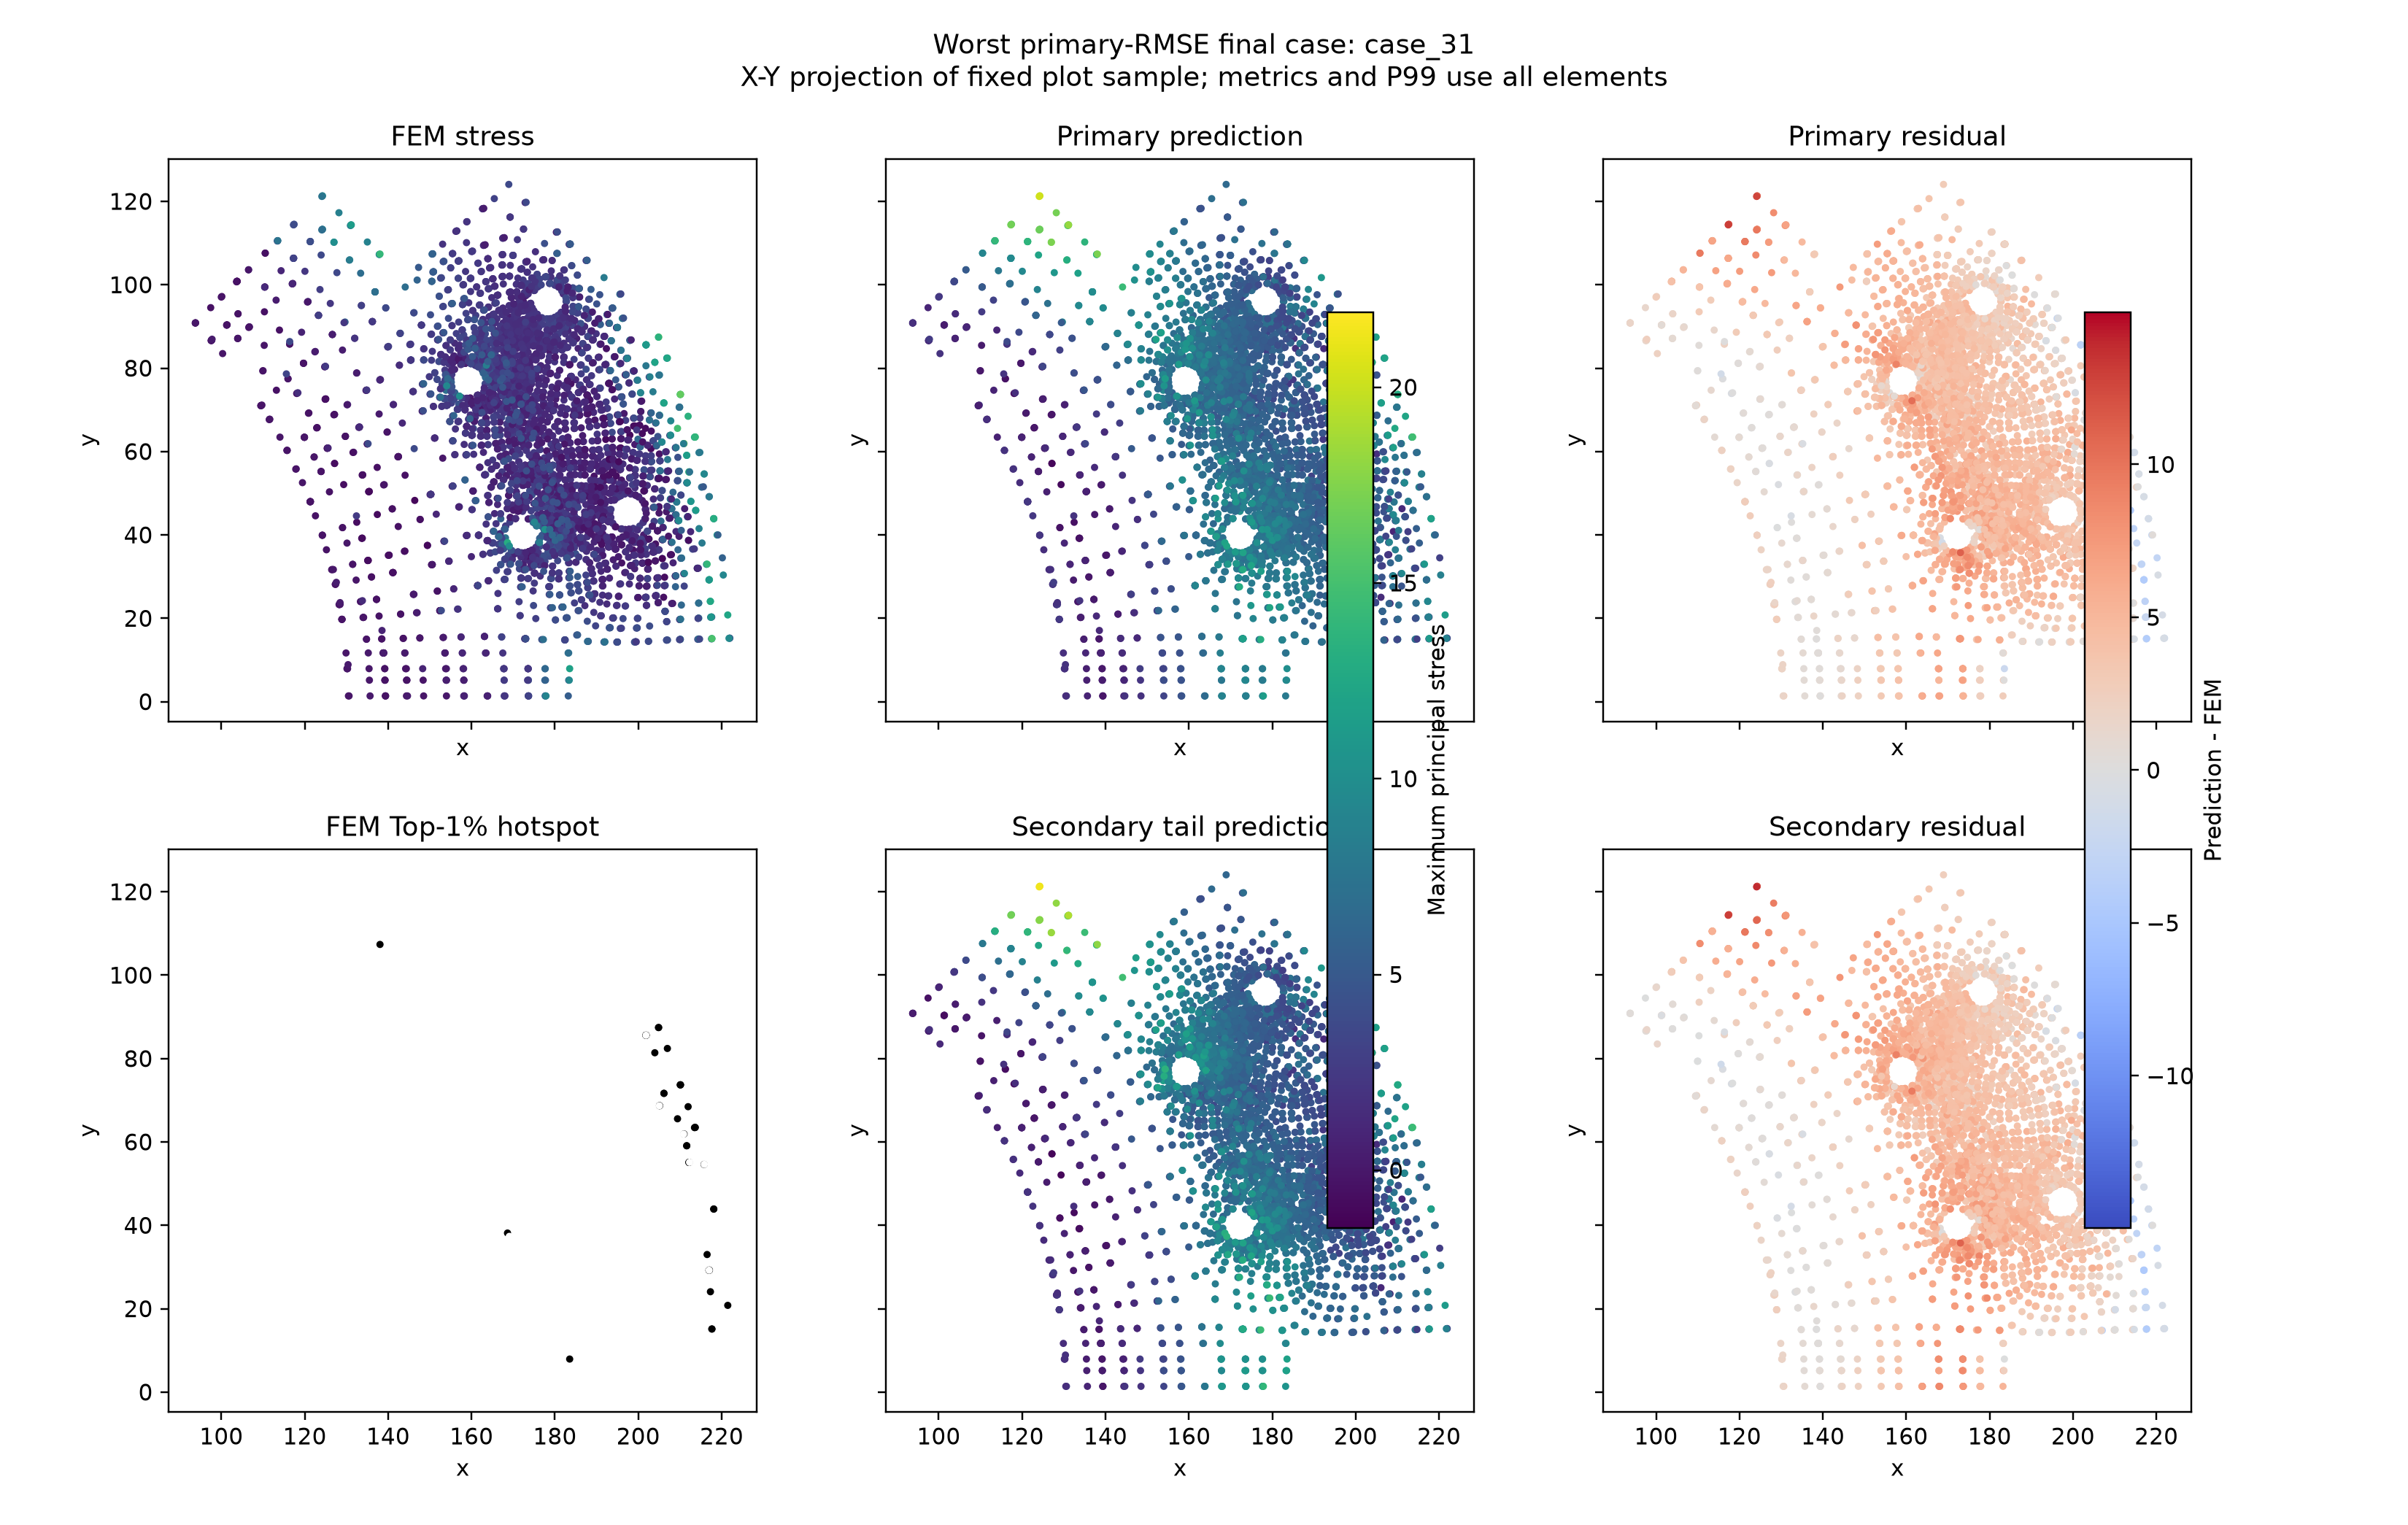

In [5]:
figure_manifest = pd.read_csv(artifacts["figures"])
figure_dir = OUTPUT_DIR / "figures_for_thesis"
for record in figure_manifest.itertuples(index=False):
    path = figure_dir / record.figure
    print(f"\n{record.figure}: {record.purpose}")
    if Image is not None:
        display(Image(filename=str(path)))


## Interpretation rule

The primary formula remains the formal result irrespective of the secondary
research model's final score. The final metrics are an unbiased estimate only
for this sealed 50-case distribution. They do not establish safety margins or
lifetimes without a separately justified strength, damage or failure model.
